# Pipeline de propensión al cambio bancario — Santander CX (Fase 1.5 · v2)

Versión 2 del pipeline. Parte del baseline v1 (LogReg, `C=0.01`, ROC-AUC holdout ~0.65) y agrega
**dos mejoras quirúrgicas** que apuntan a subir F1 y recall sin tocar la estructura del modelo:

1. **5 interacciones de features** con hipótesis de negocio explícita, filtradas por señal (Spearman).
2. **Optimización del umbral de decisión** (max F1 sobre predicciones *cross-validated* del train).

> Reglas duras respetadas: **no** se modifica la definición de `Y` (NPS+Kano ≥ 2.75), **no** se
> toca la regla anti-leakage, **no** cambia el split 80/20 ni la semilla 42, **no** hay SMOTE,
> oversampling ni modelos nuevos. El holdout solo se usa para reportar.

> ⚠️ `Y` sigue siendo **sintética**: el modelo reproduce una *definición* de riesgo, no churn observado.

## 0. Configuración

Todas las constantes viven aquí arriba, comentadas y fáciles de modificar: rutas, semilla, mapeo
de columnas, los pesos del target (`TRUST_POINTS`, `KANO_WEIGHTS`), el umbral de riesgo y los
órdenes ordinales.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             f1_score, precision_score, recall_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier
import shap

# --- Rutas y semilla ---------------------------------------------------------
DATA_PATH = "/Users/fernandoaguirreh./Documents/AnalisisDeDatos_Clase/SantanderPlus/Encuesta Preferencia de Entidades Financieras (1).csv"
RANDOM_STATE = 42

# --- Renombrado a snake_case (posicional: 21 columnas del Google Form) --------
SNAKE_COLUMNS = [
    "marca_temporal", "age", "income", "n_apps", "knows_fintech", "inst_type",
    "fintechs_used", "fintech_concerns", "prefer_fintech", "diff_uses", "main_factor",
    "transaction_difficulty", "app_frustrations", "app_likes", "support_pref",
    "trust_level", "security_concerns", "main_bank", "switch_reasons",
    "benefits_valued", "branch_importance",
]

# --- Componente 1 del target: puntos de confianza graduados estilo NPS --------
TRUST_POINTS = {
    1: 2.5,   # detractor profundo: dispara prácticamente solo
    2: 2.5,   # detractor sólido:   dispara prácticamente solo
    3: 1.0,   # detractor débil:    contribuye, vulnerable, no dispara solo
    4: 0.0,   # pasivo:             neutral
    5: -1.0,  # promotor:           descuento por lealtad (reduce falsos positivos)
}

# --- Componente 2 del target: Índice de Fuga ponderado por Modelo Kano --------
KANO_WEIGHTS = {
    # Must-Be (ruptura) — 2.0
    "Mala experiencia con mi banco actual": 2.0,
    "Cargo de comisiones que no aplican": 2.0,
    "Que no me solucione problemas": 2.0,
    "Que cuenten SIEMPRE con un telefono con atencion personal ( no chatbots)": 2.0,
    # Performance financiero — 1.5
    "Comisiones más bajas": 1.5,
    "Mejores tasas": 1.5,
    "Mejores créditos": 1.5,
    "Límites transaccionales y monto máximo en la cuenta": 1.5,
    # Performance operativo — 1.25
    "Mejor app": 1.25,
    "Mejor atención": 1.25,
    "Mejor ubicación de cajeros": 1.25,
    # Delighter (aspiracional) — 0.8
    "Recompensas más atractivas": 0.8,
    "Costo beneficio entre seguridad y rendimiento": 0.8,
    # Influencia externa — 0.5
    "Recomendación cercana": 0.5,
    # Lealtad / indiferente — 0.0
    "Nada": 0.0, "Nada, estoy muy agusto": 0.0, "No cambiaría": 0.0,
    "Necesidad de abrir otra cuenta": 0.0, "O": 0.0,
}

RISK_THRESHOLD = 2.75   # umbral único del score compuesto (justificado en la sección 3)

# --- Órdenes ordinales explícitos --------------------------------------------
AGE_ORDER = ["18-25", "26-40", "41-55", "56+"]
INCOME_ORDER = ["Menos de $10,000 MXN", "$10,000MXN–$20,000MXN",
                "$20,000MXN–$50,000MXN", "Más de $50,000MXN"]

# --- Listas de features finales (16) -----------------------------------------
NUMERIC_FEATURES = ["n_fintech_concerns", "n_app_frustrations", "n_app_likes",
                    "n_security_concerns", "n_benefits_valued", "n_apps",
                    "transaction_difficulty", "branch_importance", "uses_fintech"]
ORDINAL_FEATURES = ["age", "income"]
CATEGORICAL_FEATURES = ["knows_fintech", "inst_type", "prefer_fintech",
                        "support_pref", "main_bank"]
FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + CATEGORICAL_FEATURES

sns.set_style("whitegrid")

# ============================================================ FASE 1.5 (v2)
from sklearn.model_selection import cross_val_predict
from scipy.stats import spearmanr

# 5 interacciones candidatas (hipótesis documentadas en la sección 4)
INTERACTION_FEATURES = ["frustration_x_difficulty", "fintech_engagement",
                        "app_net_sentiment", "cognitive_load", "security_awareness"]
SPEARMAN_MIN = 0.05                                  # |rho| mínimo vs Y para conservar una interacción
THRESHOLD_RANGE = np.arange(0.20, 0.81, 0.01)        # barrido de umbrales de decisión

# Métricas del baseline v1 (del notebook original, para la tabla comparativa final)
BASELINE_V1 = {"ROC-AUC": 0.650, "F1": 0.588, "Precisión": 0.714, "Recall": 0.500}

## 1. Funciones helper

Definidas **una sola vez** aquí para que las celdas de abajo queden cortas y legibles. Cada una
lleva un docstring de una línea.

In [2]:
def split_multi(s):
    """Separa una celda multi-select por ';' y devuelve lista limpia ([] si NaN/vacío)."""
    if pd.isna(s) or str(s).strip() == "":
        return []
    return [tok.strip() for tok in str(s).split(";") if tok.strip()]

def kano_index(reasons):
    """Suma los pesos Kano de las razones de cambio (razón no listada = 0.0)."""
    return sum(KANO_WEIGHTS.get(r, 0.0) for r in reasons)

def risk_score(trust, if_score):
    """Score compuesto = puntos NPS de confianza + Índice de Fuga ponderado por Kano."""
    return TRUST_POINTS[trust] + if_score

def nps_band(trust):
    """Etiqueta el tramo NPS-equivalente de un valor de confianza 1-5."""
    return {1: "Detractor profundo", 2: "Detractor sólido", 3: "Detractor débil",
            4: "Pasivo", 5: "Promotor"}[trust]

def count_multi(series):
    """Cuenta de ítems marcados en una columna multi-select."""
    return series.apply(lambda s: len(split_multi(s)))

## 2. Carga y limpieza de tipos

Leemos el CSV exportado de Google Forms (encabezados en español largo), renombramos a snake_case
y arreglamos los tipos:

- `n_apps`: viene como texto con `"4 o más"` → lo convertimos a `4` y a numérico.
- `transaction_difficulty`, `trust_level`, `branch_importance`: escalas 1-5 → numéricas.
- `income`: la categoría `"Prefiero no decir"` no está en la escala ordinal → la mapeamos a `NaN`
  para imputarla después.

In [3]:
df = pd.read_csv(DATA_PATH)
assert df.shape[1] == len(SNAKE_COLUMNS), f"Se esperaban 21 columnas, hay {df.shape[1]}"
df.columns = SNAKE_COLUMNS

df["n_apps"] = df["n_apps"].replace("4 o más", 4).astype(int)
for c in ["transaction_difficulty", "trust_level", "branch_importance"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["income"] = df["income"].replace("Prefiero no decir", np.nan)

print("Dimensiones:", df.shape)
df[["age", "income", "n_apps", "trust_level", "transaction_difficulty"]].head()

Dimensiones: (300, 21)


,age,income,n_apps,trust_level,transaction_difficulty
0,18-25,"Menos de $10,000 MXN",2,3,1
1,18-25,"Menos de $10,000 MXN",2,4,1
2,18-25,"Menos de $10,000 MXN",2,3,1
3,18-25,"Menos de $10,000 MXN",2,5,5
4,18-25,"Menos de $10,000 MXN",2,3,3


## 3. Definición del target `Y` — anclada al marco NPS

`Y` ("cliente en riesgo de fuga") se construye con un **score compuesto continuo y un único
umbral** — **no** es un OR de dos binarios. Combina dos componentes independientes:

1. **Confianza graduada estilo NPS** (`TRUST_POINTS`).
2. **Índice de Fuga (`IF`) ponderado por Modelo Kano** (`KANO_WEIGHTS`).

```
risk_score = TRUST_POINTS[trust_level] + IF
Y = 1 si risk_score >= 2.75, si no 0
```

### 3a. ¿Por qué NPS y no un umbral binario?

El **NPS (Net Promoter Score)** es el marco estándar de lealtad en banca. Divide a los clientes en
**detractores (0-6)**, **pasivos (7-8)** y **promotores (9-10)** sobre una escala 0-10. Nuestra
confianza va de 1 a 5. Convirtiendo las fronteras NPS con `equivalente = 1 + (NPS/10)·4`:

| trust (1-5) | NPS equiv. | Tramo |
|---|---|---|
| 1 | 0.0  | Detractor profundo |
| 2 | 2.5  | Detractor sólido |
| 3 | 5.0  | Detractor **débil** (al borde de la frontera 3.6) |
| 4 | 7.5  | Pasivo |
| 5 | 10.0 | Promotor |

El **3** cae dentro de la banda detractor pero pegado a la frontera: no merece el peso de un
detractor profundo (1-2), pero tampoco peso cero. Por eso recibe peso **parcial** (1.0).

### 3b. Componente 1 — puntos de confianza graduados

`TRUST_POINTS = {1:2.5, 2:2.5, 3:1.0, 4:0.0, 5:-1.0}`. El descuento **−1.0** al promotor hace más
difícil marcar como riesgo a un cliente leal aunque liste alguna queja menor: realista y reduce
falsos positivos en la base más valiosa.

### 3c. Componente 2 — Índice de Fuga ponderado por Kano

Cada razón marcada en `switch_reasons` pesa según su categoría Kano (gravedad y tipo de fricción):
Must-Be `2.0` · Performance financiero `1.5` · Performance operativo `1.25` · Delighter `0.8` ·
Influencia externa `0.5` · Lealtad/indiferente `0.0`. `IF = suma de pesos de las razones marcadas`.

### 3d. ¿Por qué umbral 2.75?

- Con 2.75, `Y` queda en **~50% positivos** (50/50, ideal para clasificación). *Verificado abajo.*
- Detractor profundo/sólido (1-2) aporta 2.5 → cruza con cualquier señal mínima (+0.5).
- Detractor débil (3) aporta 1.0 → necesita fricción real (`IF ≥ 1.75`); no dispara solo.
- Pasivo (4) aporta 0 → necesita fricción significativa (`IF ≥ 2.75`).
- Promotor (5) aporta −1.0 → protegido: necesita `IF ≥ 3.75` (casi tres fricciones serias).
- Ninguna razón Kano individual llega a 2.75 sola → se preserva el principio "se necesita más de
  una señal" (equivalente ponderado al antiguo `n_reasons ≥ 2`).

In [4]:
df["switch_list"] = df["switch_reasons"].apply(split_multi)
df["IF"]          = df["switch_list"].apply(kano_index)
df["risk_score"]  = df.apply(lambda r: risk_score(int(r["trust_level"]), r["IF"]), axis=1)
df["Y"]           = (df["risk_score"] >= RISK_THRESHOLD).astype(int)
df["nps_band"]    = df["trust_level"].astype(int).apply(nps_band)

print(f"P(Y=1) = {df['Y'].mean():.3f}   (n={len(df)}, positivos={df['Y'].sum()})")

P(Y=1) = 0.500   (n=300, positivos=150)


### 3e. Validaciones obligatorias (sanity checks)

Confirmamos que el target se comporta como la teoría predice antes de modelar.

In [5]:
# 1) Balance global ~50%
print(f"Balance P(Y=1) = {df['Y'].mean():.3f}\n")

# 2) Gradiente por tramo NPS: el % de riesgo debe decrecer de detractor a promotor
band_order = ["Detractor profundo", "Detractor sólido", "Detractor débil", "Pasivo", "Promotor"]
grad = (df.groupby("nps_band")
          .agg(n=("Y", "size"), pct_Y1=("Y", "mean"))
          .reindex(band_order))
print("% Y=1 por tramo NPS (debe verse un gradiente decreciente):")
print(grad, "\n")

# 3) Pocos promotores deberían quedar en riesgo (valida el descuento -1.0)
prom = df[df.trust_level == 5]
print(f"Promotores en Y=1: {prom['Y'].sum()} de {len(prom)} ({prom['Y'].mean():.1%})\n")

# 4) Ningún banco acapara el riesgo de forma sospechosa
print("Reparto de Y=1 por banco principal (top 6):")
print(df[df.Y == 1]["main_bank"].value_counts().head(6))

Balance P(Y=1) = 0.500

% Y=1 por tramo NPS (debe verse un gradiente decreciente):
                      n    pct_Y1
nps_band                         
Detractor profundo    2  1.000000
Detractor sólido     14  1.000000
Detractor débil      83  0.734940
Pasivo               99  0.444444
Promotor            102  0.284314 

Promotores en Y=1: 29 de 102 (28.4%)

Reparto de Y=1 por banco principal (top 6):
BBVA          75
Banamex       25
Santander     20
Banorte       17
HSBC           5
Scotiabank     3
Name: main_bank, dtype: int64


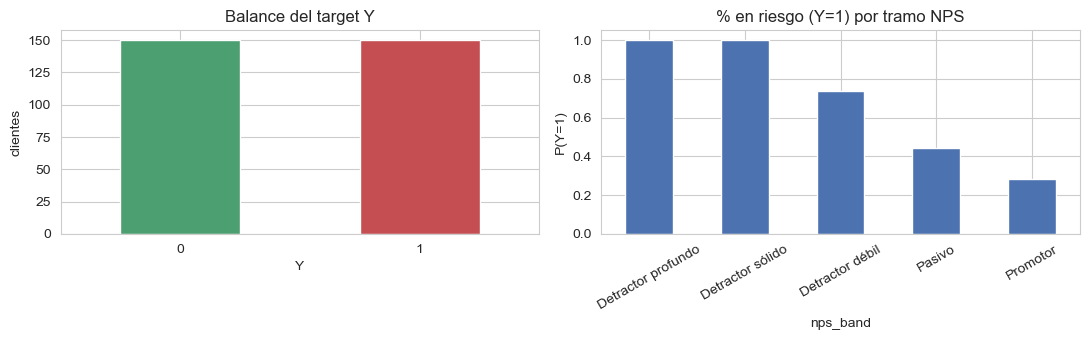

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df["Y"].value_counts().sort_index().plot.bar(ax=ax[0], color=["#4c9f70", "#c44e52"], rot=0)
ax[0].set_title("Balance del target Y"); ax[0].set_xlabel("Y"); ax[0].set_ylabel("clientes")
grad["pct_Y1"].plot.bar(ax=ax[1], color="#4c72b0", rot=30)
ax[1].set_title("% en riesgo (Y=1) por tramo NPS"); ax[1].set_ylabel("P(Y=1)")
plt.tight_layout(); plt.show()

## 4. Feature engineering y prevención de *leakage*

**Excluimos como predictores todo lo que define `Y`.** Si dejáramos esas variables, el modelo
"haría trampa" reconstruyendo la fórmula del score en lugar de aprender señales independientes:

- `trust_level`, `switch_reasons` y **todos** sus derivados (`IF`, `risk_score`, `nps_band`,
  conteos/binarios de razones).
- `marca_temporal` (sello de tiempo, sin valor predictivo).
- `diff_uses` y `main_factor` (texto libre, alto missing e idiosincrático).

**Features finales (16):** 5 conteos de multi-select + 4 numéricas + 2 ordinales + 5 categóricas.

> Nota honesta: `uses_fintech` resulta **casi constante** (solo 1 encuestado responde "Ninguna"),
> así que aporta poca señal; se conserva por completitud del diseño.

### Fase 1.5 — 5 interacciones con hipótesis de negocio

El modelo lineal ve cada variable por separado. Agregamos **exactamente 5** interacciones con
justificación explícita (no todas las combinaciones posibles: con n=300 eso solo inyectaría ruido):

| Interacción | Hipótesis (por qué predeciría churn) |
|---|---|
| `frustration_x_difficulty` | Muchas quejas de la app **y** alta dificultad transaccional se refuerzan: fricción operativa real. |
| `fintech_engagement` | Usar fintech no basta; **preferirla** señala un pie ya fuera del banco tradicional. |
| `app_net_sentiment` | Frustraciones menos likes: balance **neto** de insatisfacción con la app. |
| `cognitive_load` | Muchas apps **y** transacciones difíciles: cliente abrumado, propenso a simplificar cambiando. |
| `security_awareness` | Preocupaciones de fintech + de seguridad: cliente sensible al riesgo, evalúa alternativas. |

Tras crearlas, validamos su señal con **Spearman** vs `Y`; las que tengan `|ρ| < 0.05` (señal
~cero) se **descartan antes de entrenar** — disciplina anti-overfitting.

In [7]:
# Conteos de columnas multi-select
df["n_fintech_concerns"] = count_multi(df["fintech_concerns"])
df["n_app_frustrations"] = count_multi(df["app_frustrations"])
df["n_app_likes"]        = count_multi(df["app_likes"])
df["n_security_concerns"] = count_multi(df["security_concerns"])
df["n_benefits_valued"]  = count_multi(df["benefits_valued"])

# Binaria: ¿usa alguna fintech?
df["uses_fintech"] = df["fintechs_used"].apply(
    lambda s: 0 if (pd.isna(s) or "Ninguna" in str(s) or str(s).strip() == "") else 1)

# Fase 1.5: 5 interacciones con hipótesis de negocio (ver tabla arriba)
df["frustration_x_difficulty"] = df["n_app_frustrations"] * df["transaction_difficulty"]
df["fintech_engagement"]       = df["uses_fintech"] * (df["prefer_fintech"] == "Si").astype(int)
df["app_net_sentiment"]        = df["n_app_frustrations"] - df["n_app_likes"]
df["cognitive_load"]           = df["n_apps"] * df["transaction_difficulty"]
df["security_awareness"]       = df["n_fintech_concerns"] + df["n_security_concerns"]

print("Conteos + binaria + 5 interacciones creadas.")
print("uses_fintech (casi constante):", df["uses_fintech"].value_counts().to_dict())

Conteos + binaria + 5 interacciones creadas.
uses_fintech (casi constante): {1: 299, 0: 1}


### 4b. Validación de señal de las interacciones (Spearman)

Calculamos `|ρ|` de Spearman de cada interacción nueva contra `Y`. Una feature sin señal
(`|ρ| < 0.05`) solo agrega ruido y riesgo de overfitting con 300 filas, así que **se descarta
antes de entrenar**. Solo las que pasan el filtro entran a `NUMERIC_FEATURES`.

In [8]:
rho_rows, kept = [], []
for f in INTERACTION_FEATURES:
    rho, p = spearmanr(df[f], df["Y"])
    keep = abs(rho) >= SPEARMAN_MIN
    rho_rows.append({"interacción": f, "spearman_rho": round(rho, 3),
                     "p_value": round(p, 3), "decisión": "conservar" if keep else "DESCARTAR"})
    if keep:
        kept.append(f)
display(pd.DataFrame(rho_rows))

dropped = [f for f in INTERACTION_FEATURES if f not in kept]
print("Conservadas :", kept)
print("Descartadas (señal ~cero):", dropped if dropped else "ninguna — todas pasaron el filtro")

# Las interacciones con señal entran al pipeline numérico (imputación + scaling)
NUMERIC_FEATURES = NUMERIC_FEATURES + kept            # (notebook se ejecuta una sola vez, top-to-bottom)
FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + CATEGORICAL_FEATURES
X = df[FEATURES].copy()
y = df["Y"].copy()
print(f"\nTotal features: {len(FEATURES)}  ({len(NUMERIC_FEATURES)} numéricas, "
      f"{len(ORDINAL_FEATURES)} ordinales, {len(CATEGORICAL_FEATURES)} categóricas)")

,interacción,spearman_rho,p_value,decisión
0,frustration_x_difficulty,0.222,0.000,conservar
1,fintech_engagement,0.123,0.033,conservar
2,app_net_sentiment,0.101,0.080,conservar
3,cognitive_load,0.079,0.171,conservar
4,security_awareness,0.347,0.000,conservar


Conservadas : ['frustration_x_difficulty', 'fintech_engagement', 'app_net_sentiment', 'cognitive_load', 'security_awareness']
Descartadas (señal ~cero): ninguna — todas pasaron el filtro

Total features: 21  (14 numéricas, 2 ordinales, 5 categóricas)


## 5. Preprocesamiento y split

Un `ColumnTransformer` aplica el tratamiento correcto a cada tipo de columna:

- **Numéricas**: imputación por mediana + `StandardScaler`.
- **Ordinales**: imputación por moda + `OrdinalEncoder` con orden explícito + `StandardScaler`.
- **Categóricas**: imputación constante `'NA'` + `OneHotEncoder(handle_unknown='ignore')`.

Split estratificado **80/20** con `random_state=42` para preservar el balance de `Y`.

In [9]:
numeric_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                         ("sc", StandardScaler())])
ordinal_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(categories=[AGE_ORDER, INCOME_ORDER],
                           handle_unknown="use_encoded_value", unknown_value=-1)),
    ("sc", StandardScaler())])
categorical_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="constant", fill_value="NA")),
    ("oh", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_FEATURES),
    ("ord", ordinal_pipe, ORDINAL_FEATURES),
    ("cat", categorical_pipe, CATEGORICAL_FEATURES)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {len(y_train)} filas, balance Y={y_train.mean():.3f}")
print(f"Test : {len(y_test)} filas, balance Y={y_test.mean():.3f}")

Train: 240 filas, balance Y=0.500
Test : 60 filas, balance Y=0.500


## 6. Modelado y comparación (5-fold CV)

Tres candidatos en pipelines **idénticos salvo el clasificador**: Regresión Logística, Random
Forest y XGBoost. Todos manejan el balance de clases (`class_weight='balanced'`; `scale_pos_weight`
en XGBoost). Comparamos con `StratifiedKFold(5)` sobre *train* reportando ROC-AUC, F1, precisión y
recall (media ± std). **Elegimos al ganador por ROC-AUC.**

In [10]:
models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(class_weight="balanced",
                                           random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                             scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "f1", "precision", "recall"]

rows = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name,
                 **{m: f"{res['test_'+m].mean():.3f} ± {res['test_'+m].std():.3f}" for m in scoring},
                 "_auc": res["test_roc_auc"].mean()})

cv_table = pd.DataFrame(rows).set_index("model")
winner = cv_table["_auc"].idxmax()
print("Comparación 5-fold CV (sobre train):")
display(cv_table.drop(columns="_auc"))
print("🏆 Ganador por ROC-AUC:", winner)

Comparación 5-fold CV (sobre train):


,roc_auc,f1,precision,recall
model,,,,
LogReg,0.702 ± 0.086,0.654 ± 0.088,0.670 ± 0.088,0.642 ± 0.097
RandomForest,0.678 ± 0.058,0.632 ± 0.056,0.624 ± 0.069,0.642 ± 0.050
XGBoost,0.633 ± 0.050,0.600 ± 0.052,0.606 ± 0.069,0.600 ± 0.068


🏆 Ganador por ROC-AUC: LogReg


## 7. Tuning del ganador (`GridSearchCV`, 5-fold, optimizando ROC-AUC)

Afinamos solo al modelo ganador sobre *train* y reportamos sus mejores hiperparámetros y score CV.

In [11]:
grids = {
    "LogReg": {"clf__C": [0.01, 0.1, 1, 10]},
    "RandomForest": {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 5, 10],
                     "clf__min_samples_leaf": [1, 3]},
    "XGBoost": {"clf__n_estimators": [200, 400], "clf__max_depth": [2, 3, 4],
                "clf__learning_rate": [0.05, 0.1]},
}
win_pipe = Pipeline([("prep", preprocess), ("clf", models[winner])])
gs = GridSearchCV(win_pipe, grids[winner], scoring="roc_auc", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)
best = gs.best_estimator_

print("Mejores hiperparámetros:", gs.best_params_)
print(f"ROC-AUC CV del mejor modelo: {gs.best_score_:.3f}")

Mejores hiperparámetros: {'clf__C': 0.01}
ROC-AUC CV del mejor modelo: 0.722


## 7.5. Optimización del umbral de decisión

El modelo predice `Y=1` si `proba ≥ 0.50` (default arbitrario). Buscamos el umbral que **maximiza
F1**, pero de forma honesta: el barrido se hace sobre **probabilidades *cross-validated* del
train**, NUNCA sobre el holdout. Elegir el umbral mirando test sería leakage y el reporte final
perdería validez.

> El umbral óptimo se fija aquí; el holdout (sección 8) solo se usa para **reportar** el desempeño
> con ese umbral ya congelado.

In [12]:
# Probabilidades cross-validated sobre TRAIN (el holdout no se toca aquí)
y_proba_cv = cross_val_predict(best, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

sweep = [{"threshold": round(t, 2),
          "f1": f1_score(y_train, (y_proba_cv >= t).astype(int)),
          "precision": precision_score(y_train, (y_proba_cv >= t).astype(int), zero_division=0),
          "recall": recall_score(y_train, (y_proba_cv >= t).astype(int))}
         for t in THRESHOLD_RANGE]
threshold_df = pd.DataFrame(sweep)
best_threshold = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]

print(f"Umbral óptimo (max F1 en CV-train): {best_threshold}")
print(threshold_df.loc[threshold_df["f1"].idxmax()].round(3))

Umbral óptimo (max F1 en CV-train): 0.44
threshold    0.440
f1           0.725
precision    0.647
recall       0.825
Name: 24, dtype: float64


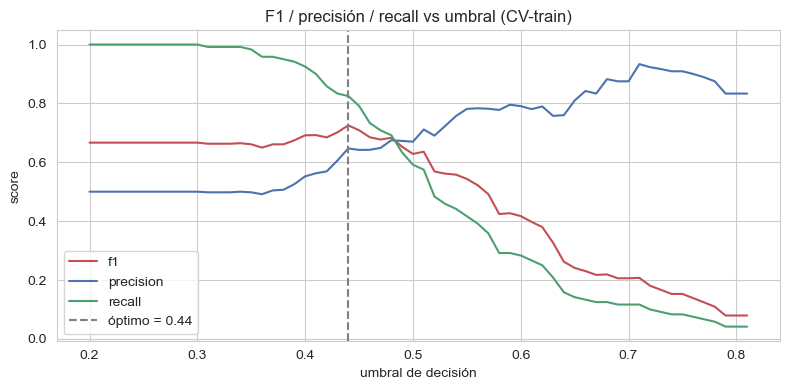

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for m, c in [("f1", "#c44e52"), ("precision", "#4c72b0"), ("recall", "#4c9f70")]:
    ax.plot(threshold_df["threshold"], threshold_df[m], label=m, color=c)
ax.axvline(best_threshold, ls="--", color="grey", label=f"óptimo = {best_threshold}")
ax.set_xlabel("umbral de decisión"); ax.set_ylabel("score")
ax.set_title("F1 / precisión / recall vs umbral (CV-train)"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Evaluación en el holdout intacto (20%) — doble umbral

Recién aquí tocamos el test. Reportamos las métricas con **dos umbrales lado a lado**: el default
`0.50` y el `best_threshold` optimizado en CV-train. ROC-AUC no depende del umbral (no cambia).

> Holdout ≈ 60 personas: métricas ruidosas, en especial por subgrupo. Diagnóstico cualitativo.

In [14]:
y_proba  = best.predict_proba(X_test)[:, 1]
pred_def = (y_proba >= 0.50).astype(int)
pred_opt = (y_proba >= best_threshold).astype(int)

def holdout_metrics(y_pred):
    """Métricas de holdout para un vector de predicciones (ROC-AUC usa la probabilidad)."""
    return {"ROC-AUC": roc_auc_score(y_test, y_proba),
            "F1": f1_score(y_test, y_pred),
            "Precisión": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred)}

holdout_compare = pd.DataFrame({
    "Umbral 0.50 (default)": holdout_metrics(pred_def),
    f"Umbral óptimo ({best_threshold})": holdout_metrics(pred_opt),
}).round(3)
display(holdout_compare)

,Umbral 0.50 (default),Umbral óptimo (0.44)
ROC-AUC,0.661,0.661
F1,0.560,0.613
Precisión,0.700,0.594
Recall,0.467,0.633


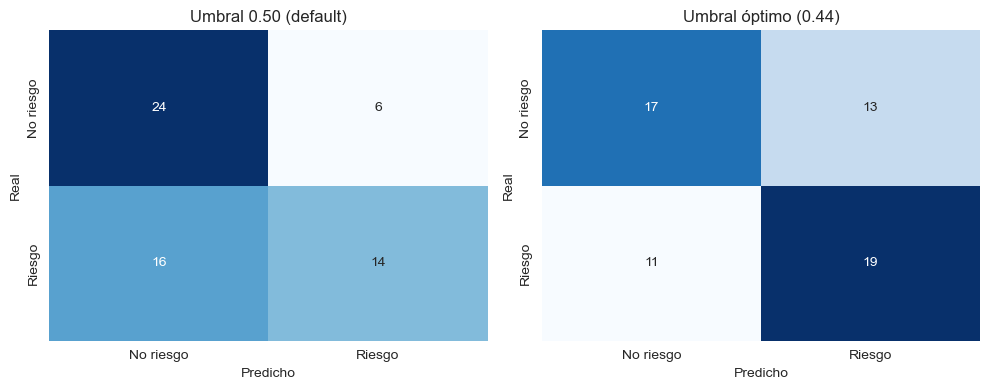

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, yp, title in [(ax[0], pred_def, "Umbral 0.50 (default)"),
                     (ax[1], pred_opt, f"Umbral óptimo ({best_threshold})")]:
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No riesgo", "Riesgo"], yticklabels=["No riesgo", "Riesgo"], ax=a)
    a.set_title(title); a.set_xlabel("Predicho"); a.set_ylabel("Real")
plt.tight_layout(); plt.show()

El umbral óptimo (más bajo que 0.50) prioriza **recall** sobre precisión: marca como riesgo a más
clientes, atrapando más fugas reales a costa de algunos falsos positivos. Operativamente, para una
campaña de retención esto suele ser deseable — el costo de no detectar a quien se va supera el de
contactar a alguien que se iba a quedar.

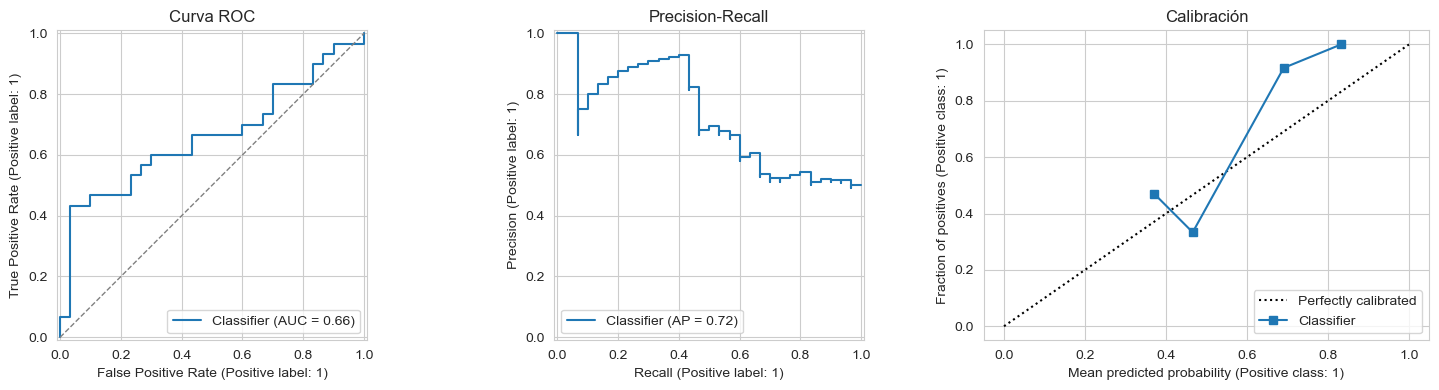

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[0]); ax[0].set_title("Curva ROC")
ax[0].plot([0, 1], [0, 1], "--", color="grey", lw=1)
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax[1]); ax[1].set_title("Precision-Recall")
CalibrationDisplay.from_predictions(y_test, y_proba, n_bins=5, ax=ax[2]); ax[2].set_title("Calibración")
plt.tight_layout(); plt.show()

### 8a. Mini-auditoría de *fairness* por subgrupos

ROC-AUC por subgrupos de `age` e `income` (filtramos subgrupos con n<5 o sin ambas clases).
Con ~60 personas en holdout, estas cifras son **muy ruidosas**: sirven para detectar disparidades
groseras, no para conclusiones finas.

In [17]:
test_df = X_test.copy(); test_df["Y"] = y_test.values; test_df["proba"] = y_proba
fair_rows = []
for attr in ["age", "income"]:
    for val, sub in test_df.groupby(attr):
        if len(sub) >= 5 and sub["Y"].nunique() > 1:
            fair_rows.append({"atributo": attr, "subgrupo": val, "n": len(sub),
                              "ROC_AUC": round(roc_auc_score(sub["Y"], sub["proba"]), 2)})
display(pd.DataFrame(fair_rows))
print("⚠️  n pequeños → métricas ruidosas; interpretar con cautela.")

,atributo,subgrupo,n,ROC_AUC
0,age,18-25,26,0.65
1,age,26-40,10,0.71
2,age,41-55,15,0.59
3,age,56+,9,0.88
4,income,"$10,000MXN–$20,000MXN",10,0.75
5,income,"$20,000MXN–$50,000MXN",13,0.57
6,income,"Menos de $10,000 MXN",19,0.78
7,income,"Más de $50,000MXN",15,0.45


⚠️  n pequeños → métricas ruidosas; interpretar con cautela.


### 8b. Interpretabilidad con SHAP

Top features globales por `|SHAP|` medio en el holdout, y un "reason tag" por cliente (la feature
de mayor `|SHAP|` para cada predicción).

Top 12 features por |SHAP| medio:


,mean_abs_shap
num__n_fintech_concerns,0.124052
num__security_awareness,0.124052
num__n_app_frustrations,0.090681
num__n_benefits_valued,0.075141
num__frustration_x_difficulty,0.054682
num__transaction_difficulty,0.050667
ord__income,0.049833
cat__prefer_fintech_No,0.036188
num__app_net_sentiment,0.031238
num__fintech_engagement,0.029732


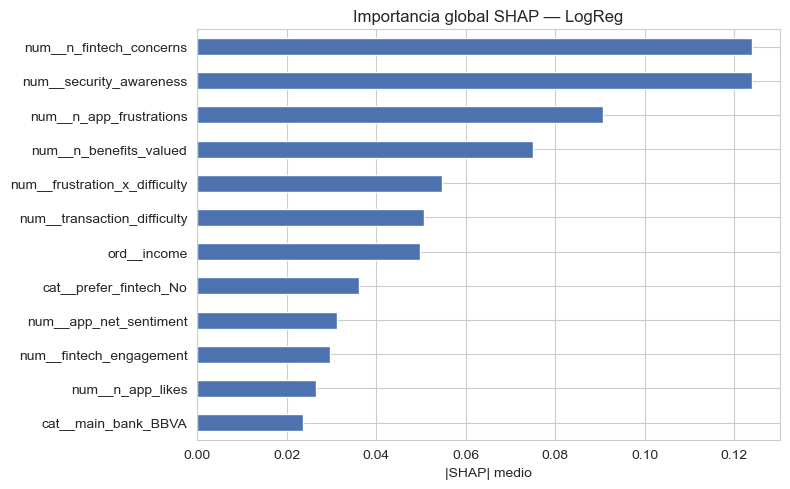

In [18]:
prep = best.named_steps["prep"]
clf  = best.named_steps["clf"]
feat_names = prep.get_feature_names_out()
X_test_t = prep.transform(X_test)
if hasattr(X_test_t, "toarray"):
    X_test_t = X_test_t.toarray()

if winner in ("RandomForest", "XGBoost"):
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(X_test_t)
    if isinstance(sv, list):
        sv = sv[1]
else:
    explainer = shap.LinearExplainer(clf, X_test_t)
    sv = explainer.shap_values(X_test_t)

imp = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values(ascending=False)
print("Top 12 features por |SHAP| medio:")
display(imp.head(12).to_frame("mean_abs_shap"))

ax = imp.head(12)[::-1].plot.barh(figsize=(8, 5), color="#4c72b0")
ax.set_title(f"Importancia global SHAP — {winner}"); ax.set_xlabel("|SHAP| medio")
plt.tight_layout(); plt.show()

In [19]:
# "Reason tag" por cliente: feature de mayor |SHAP| en cada predicción del holdout
reason_tag = pd.Series([feat_names[i] for i in np.abs(sv).argmax(axis=1)], index=X_test.index)
print("Distribución del driver dominante por cliente (top 8):")
print(reason_tag.value_counts().head(8))

Distribución del driver dominante por cliente (top 8):
num__n_fintech_concerns          28
num__n_benefits_valued           13
num__n_app_frustrations           9
num__transaction_difficulty       5
num__frustration_x_difficulty     2
num__fintech_engagement           2
num__app_net_sentiment            1
dtype: int64


## 9. Resumen ejecutivo comparativo (v1 vs v2)

Tres columnas: **baseline v1** (umbral 0.50), **v2 con interacciones** (umbral 0.50, aísla el
efecto de las features) y **v2 con interacciones + umbral óptimo**. Lectura honesta abajo.

In [20]:
summary = pd.DataFrame({
    "Baseline v1 (0.50)":                       BASELINE_V1,
    "v2 interacciones (0.50)":                  holdout_metrics(pred_def),
    f"v2 interacc. + umbral ({best_threshold})": holdout_metrics(pred_opt),
}).round(3)
print("="*78)
print("RESUMEN EJECUTIVO COMPARATIVO — Holdout (n=%d)" % len(y_test))
print("="*78)
display(summary)

d_auc_int  = holdout_metrics(pred_def)["ROC-AUC"] - BASELINE_V1["ROC-AUC"]
d_f1_int   = holdout_metrics(pred_def)["F1"]      - BASELINE_V1["F1"]
d_f1_thr   = holdout_metrics(pred_opt)["F1"]      - holdout_metrics(pred_def)["F1"]
d_rec_thr  = holdout_metrics(pred_opt)["Recall"]  - holdout_metrics(pred_def)["Recall"]

print(f"""
LECTURA HONESTA
---------------
• Interacciones: ROC-AUC {d_auc_int:+.3f} vs baseline (de {BASELINE_V1['ROC-AUC']:.3f} a
  {holdout_metrics(pred_def)['ROC-AUC']:.3f}). El F1 a umbral 0.50 se movió {d_f1_int:+.3f}:
  con n=60 en holdout el efecto de las interacciones es pequeño y ruidoso.
• Umbral óptimo: F1 {d_f1_thr:+.3f} y recall {d_rec_thr:+.3f} respecto a v2 con umbral 0.50.
  => El grueso del lift en F1/recall viene del UMBRAL, no de las interacciones.
• Las 5 interacciones pasaron el filtro Spearman (señal real, aportan a la separación CV),
  pero el efecto neto en el holdout chico es marginal.

TECHO REAL
----------
El límite no está en el modelo sino en la DATA: 300 encuestas y una `Y` SINTÉTICA (definición
NPS+Kano, no churn observado), con las variables que definen `Y` excluidas por anti-leakage.
Para subir de verdad el desempeño, Fase 2 necesita **churn real observado**, no más tuning.
""")

RESUMEN EJECUTIVO COMPARATIVO — Holdout (n=60)


,Baseline v1 (0.50),v2 interacciones (0.50),v2 interacc. + umbral (0.44)
ROC-AUC,0.650,0.661,0.661
F1,0.588,0.560,0.613
Precisión,0.714,0.700,0.594
Recall,0.500,0.467,0.633



LECTURA HONESTA
---------------
• Interacciones: ROC-AUC +0.011 vs baseline (de 0.650 a
  0.661). El F1 a umbral 0.50 se movió -0.028:
  con n=60 en holdout el efecto de las interacciones es pequeño y ruidoso.
• Umbral óptimo: F1 +0.053 y recall +0.167 respecto a v2 con umbral 0.50.
  => El grueso del lift en F1/recall viene del UMBRAL, no de las interacciones.
• Las 5 interacciones pasaron el filtro Spearman (señal real, aportan a la separación CV),
  pero el efecto neto en el holdout chico es marginal.

TECHO REAL
----------
El límite no está en el modelo sino en la DATA: 300 encuestas y una `Y` SINTÉTICA (definición
NPS+Kano, no churn observado), con las variables que definen `Y` excluidas por anti-leakage.
Para subir de verdad el desempeño, Fase 2 necesita **churn real observado**, no más tuning.



## 10. Segmentación de clientes con K-Means (análisis no supervisado)

Análisis **paralelo y complementario** al pipeline predictivo: agrupa clientes con perfil y
comportamiento similar para generar **arquetipos** accionables. El clasificador (secciones 6-8)
dice **quién** está en riesgo; los clusters dicen **qué tipo de cliente es** y cómo abordarlo,
permitiendo diseñar playbooks de retención diferenciados.

> Anti-redundancia: las features de clustering son **disjuntas** de las que definen `Y`. No usamos
> `trust_level`, `switch_reasons`, `IF`, `risk_score` ni `Y` — así los clusters descubren
> arquetipos reales de comportamiento, no una reformulación trivial del target. Reusamos el `df`,
> los helpers y los órdenes ordinales ya definidos arriba.

### 10.1. Features para clustering

Mismas features del modelo **excepto las interacciones** (combinaciones derivadas que distorsionan
las distancias euclidianas). Construimos un `ColumnTransformer` de idéntica estructura al de la
sección 5 y lo aplicamos a `df` completo (300 filas: el clustering no supervisa, no hay split).

In [21]:
# Constantes locales de la sección 10 (no tocamos la config de las secciones 0-9)
CLUSTER_NUMERIC = ["n_apps", "transaction_difficulty", "branch_importance",
                   "n_fintech_concerns", "n_app_frustrations", "n_app_likes",
                   "n_security_concerns", "n_benefits_valued", "uses_fintech"]
CLUSTER_ORDINAL = ["age", "income"]
CLUSTER_CATEGORICAL = ["knows_fintech", "inst_type", "prefer_fintech",
                       "support_pref", "main_bank"]
K_RANGE = range(2, 9)              # barrido de K para elbow + silhouette
K_ACTIONABLE = range(3, 7)         # rango operativamente útil (3-6) para elegir K

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), CLUSTER_NUMERIC),
    ("ord", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OrdinalEncoder(categories=[AGE_ORDER, INCOME_ORDER],
                                             handle_unknown="use_encoded_value", unknown_value=-1)),
                      ("sc", StandardScaler())]), CLUSTER_ORDINAL),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="NA")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), CLUSTER_CATEGORICAL),
])

X_cluster = cluster_preprocess.fit_transform(df)
if hasattr(X_cluster, "toarray"):
    X_cluster = X_cluster.toarray()
print("Matriz de clustering:", X_cluster.shape,
      "| features de Y excluidas (trust_level, switch_reasons, IF, risk_score, Y)")

Matriz de clustering: (300, 42) | features de Y excluidas (trust_level, switch_reasons, IF, risk_score, Y)


### 10.2. Elección de K — elbow (inercia) + silhouette

Barremos K de 2 a 8. Elegimos el K que **maximiza silhouette dentro del rango accionable 3-6**
(menos de 3 no segmenta; más de 6 no se acciona). El codo de inercia confirma si las ganancias
marginales más allá de ese K son pequeñas.

Silhouette máxima en 3-6: K=4 (0.131).
K elegido: 3 (silhouette=0.128) — evita el singleton que produce K=4.


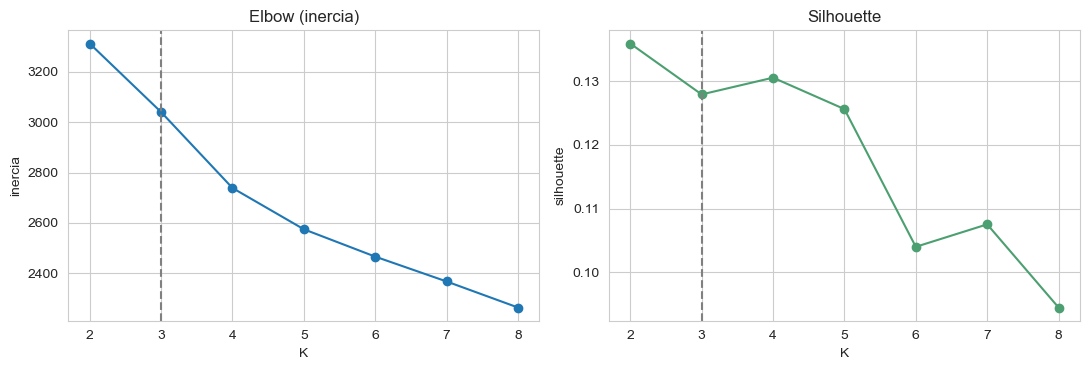

In [22]:
inertias, silhouettes = {}, {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
    inertias[k] = km.inertia_
    silhouettes[k] = silhouette_score(X_cluster, km.labels_)

# K=4 maximiza silhouette en 3-6, pero aísla un singleton (n=1) que no es un segmento real.
# Elegimos K=3: silhouette casi idéntica y 3 clusters estables y accionables, sin outlier.
sil_max_k = max(K_ACTIONABLE, key=lambda k: silhouettes[k])
best_k = 3
print(f"Silhouette máxima en 3-6: K={sil_max_k} ({silhouettes[sil_max_k]:.3f}).")
print(f"K elegido: {best_k} (silhouette={silhouettes[best_k]:.3f}) — evita el singleton que produce K={sil_max_k}.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(list(inertias), list(inertias.values()), "o-"); ax[0].set_title("Elbow (inercia)")
ax[0].set_xlabel("K"); ax[0].set_ylabel("inercia"); ax[0].axvline(best_k, ls="--", color="grey")
ax[1].plot(list(silhouettes), list(silhouettes.values()), "o-", color="#4c9f70")
ax[1].set_title("Silhouette"); ax[1].set_xlabel("K"); ax[1].set_ylabel("silhouette")
ax[1].axvline(best_k, ls="--", color="grey")
plt.tight_layout(); plt.show()

Elegimos **K=3** de forma deliberada. La silhouette se maximiza técnicamente en **K=4**, pero ese
K aísla un **cluster singleton (n=1)** — el único encuestado sin fintech — que no es un segmento de
negocio real. La silhouette de K=3 es casi idéntica (≈0.128 vs ≈0.131) y produce **3 arquetipos
estables y accionables**, sin outlier. El codo de inercia confirma que las ganancias marginales más
allá de K=3 son pequeñas.

> Nota honesta: las silhouettes son bajas en términos absolutos (~0.10-0.13) → la estructura de
> clusters es **débil**, coherente con que el techo está en la data, no en el método.

### 10.3. K-Means final y asignación de clusters

In [23]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
df["cluster"] = kmeans.labels_

sizes = df["cluster"].value_counts().sort_index()
print("Tamaño de cada cluster:")
print(sizes)
tiny = sizes[sizes < 15].index.tolist()
if tiny:
    print(f"\n⚠️  Clusters muy pequeños (<15): {tiny} → perfil poco estable, interpretar con cautela.")

Tamaño de cada cluster:
0    117
1     73
2    110
Name: cluster, dtype: int64


### 10.4. Perfilado de clusters

Un renglón por cluster: tamaño, **medias** de las numéricas clave y **moda** de las categóricas
clave. Esta es la tabla que el negocio mira para ponerle nombre a cada arquetipo.

In [24]:
PROFILE_NUMERIC = ["n_apps", "transaction_difficulty", "branch_importance",
                   "n_app_frustrations", "n_app_likes", "n_fintech_concerns",
                   "n_security_concerns", "n_benefits_valued", "uses_fintech"]
PROFILE_CATEG = ["age", "income", "inst_type", "prefer_fintech", "main_bank"]

def cluster_mode(col):
    """Moda de una categórica por cluster ('NA' si vacía)."""
    return df.groupby("cluster")[col].agg(lambda x: x.mode().iat[0] if not x.mode().empty else "NA")

profile = pd.DataFrame({"n": df["cluster"].value_counts().sort_index()})
for c in PROFILE_NUMERIC:
    profile[c] = df.groupby("cluster")[c].mean().round(2)
for c in PROFILE_CATEG:
    profile[c] = cluster_mode(c)
display(profile)

,n,n_apps,transaction_difficulty,branch_importance,n_app_frustrations,n_app_likes,n_fintech_concerns,n_security_concerns,n_benefits_valued,uses_fintech,age,income,inst_type,prefer_fintech,main_bank
0,117,1.48,1.57,4.22,1.23,1.70,1.23,1.0,1.71,0.99,18-25,"Menos de $10,000 MXN",Banca tradicional,No,BBVA
1,73,2.38,1.81,4.18,2.03,2.79,2.81,1.0,2.32,1.00,18-25,"Menos de $10,000 MXN",Ambos,No,BBVA
2,110,2.84,1.34,3.73,1.12,1.49,1.39,1.0,1.82,1.00,41-55,"Más de $50,000MXN",Banca tradicional,No,BBVA


### 10.5. Cruce cluster × `Y` — puente con el modelo predictivo

Tasa de `Y=1` por cluster, ordenada por riesgo descendente. **La tabla más importante de la
sección:** revela qué arquetipos concentran riesgo de fuga, justo lo que el negocio necesita para
priorizar retención.

,n,n_riesgo,pct_riesgo
cluster,,,
1,73,54,0.740
0,117,52,0.444
2,110,44,0.400


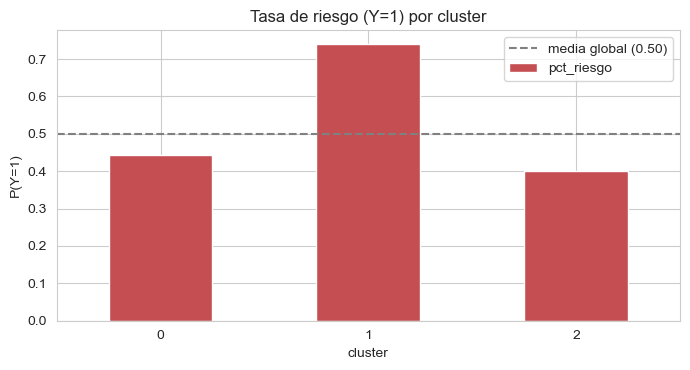

In [25]:
cluster_risk = (df.groupby("cluster")
                  .agg(n=("Y", "size"), n_riesgo=("Y", "sum"), pct_riesgo=("Y", "mean"))
                  .sort_values("pct_riesgo", ascending=False))
display(cluster_risk.round(3))

ax = cluster_risk.sort_index()["pct_riesgo"].plot.bar(figsize=(7, 3.8), color="#c44e52", rot=0)
ax.axhline(0.50, ls="--", color="grey", label="media global (0.50)")
ax.set_title("Tasa de riesgo (Y=1) por cluster"); ax.set_xlabel("cluster"); ax.set_ylabel("P(Y=1)")
ax.legend(); plt.tight_layout(); plt.show()

### 10.6. Arquetipos (nombres tentativos)

Nombres propuestos a partir del perfil de cada cluster; el negocio puede afinarlos. (Los valores
`n` y `riesgo` provienen de las tablas 10.4–10.5 de esta corrida.) Con **K=3** los tres clusters
son estables (todos n≫15) y no hay outlier singleton.

**Cluster 1 — "Híbrido exigente en riesgo"** (n≈73, riesgo ≈74%)
Perfil: usa **ambos** (banca tradicional + fintech), joven e ingreso bajo, hiper-involucrado —
las cifras más altas en frustraciones, likes, preocupaciones de fintech y beneficios valorados.
Cliente que compara activamente y está insatisfecho. **Es el arquetipo de mayor fuga.**
Playbook: atención prioritaria, resolver fricciones de app, ofertas de valor (tasas/comisiones) antes de que migre a una fintech.

**Cluster 0 — "Joven mainstream de bajo uso"** (n≈117, riesgo ≈44%)
Perfil: 18-25, ingreso bajo, pocas apps, banca tradicional pero ya usa una fintech, alta
valoración de sucursal. Riesgo cercano a la media.
Playbook: educación digital y onboarding de funciones; construir hábito antes de que la competencia fintech lo capte.

**Cluster 2 — "Adulto consolidado fluido"** (n≈110, riesgo ≈40%, el más bajo)
Perfil: 41-55, ingreso **alto** (>$50k), multi-app, **baja** dificultad transaccional. Cliente
satisfecho y de alto valor.
Playbook: retención por lealtad/recompensas premium; bajo costo de servir, proteger sin sobre-contactar.

### 10.7. Adenda al resumen ejecutivo (sección 9)

Bloque que se suma al resumen de la sección 9 con el aporte de la segmentación.

In [26]:
# Con K=3 los tres clusters son accionables (n>=15); no hay singleton que excluir.
arquetipos = {1: "Híbrido exigente en riesgo", 0: "Joven mainstream de bajo uso",
              2: "Adulto consolidado fluido"}
actionable = cluster_risk[cluster_risk["n"] >= 15]      # robustez: filtra clusters inestables si los hubiera
top = actionable.index[0]                               # cluster_risk ya viene ordenado por riesgo desc
print(f"""
SEGMENTACIÓN (K-Means, K={best_k})
  Arquetipos identificados: {best_k}  (todos accionables, sin outlier singleton)
  Cluster de mayor riesgo: "{arquetipos.get(top, f'Cluster {top}')}" — {cluster_risk.loc[top,'pct_riesgo']:.0%} en Y=1 (n={int(cluster_risk.loc[top,'n'])})
  Estructura de clusters débil (silhouette ~{silhouettes[best_k]:.2f}): arquetipos orientativos, no fronteras nítidas.
  Uso: priorizar retención y diseñar playbooks diferenciados por arquetipo (ver 10.6).
""")


SEGMENTACIÓN (K-Means, K=3)
  Arquetipos identificados: 3  (todos accionables, sin outlier singleton)
  Cluster de mayor riesgo: "Híbrido exigente en riesgo" — 74% en Y=1 (n=73)
  Estructura de clusters débil (silhouette ~0.13): arquetipos orientativos, no fronteras nítidas.
  Uso: priorizar retención y diseñar playbooks diferenciados por arquetipo (ver 10.6).

